|                |   |
:----------------|---|
| **Nombre**     |Santiago Escutia Ríos   |
| **Fecha**      | 9/4/2026  |
| **Expediente** |757839   |

## A06 - Brain Tumor SVC

Este trabajo tiene como objetivo clasificar tumores cerebrales como benignos o malignos utilizando un modelo de Support Vector Classifier (SVC) con kernel lineal. El hiperparámetro de regularización C se optimiza mediante optimización bayesiana, evaluando el desempeño con el AUC y validación cruzada estratificada de 10 folds.

Se utiliza el dataset **Brain Tumor**, el cual contiene información clínica y demográfica de pacientes.  
La variable objetivo es `Tumor_Type`, que indica si el tumor es **benigno** o **maligno**.  
La columna `Patient_ID` se elimina por no aportar información predictiva.

In [10]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from skopt import BayesSearchCV
from skopt.space import Real


df = pd.read_csv('brain_tumor_dataset.csv')

In [11]:
if len(df) > 5000:
    df = df.sample(n=5000, random_state=42)


Se generaron histogramas para las variables numéricas clave con el fin de observar la capacidad de separación entre tumores Benignos y Malignos.

* **Observación:** Las distribuciones de las clases están prácticamente superpuestas en todas las variables (Edad, Tamaño, Tasa de Crecimiento).
* **Conclusión Técnica:** Esta superposición visual confirma por qué el modelo SVC Lineal obtiene un AUC de 0.50. No existe un umbral o "corte" claro que permita distinguir una clase de otra basándose en estas características de forma lineal.

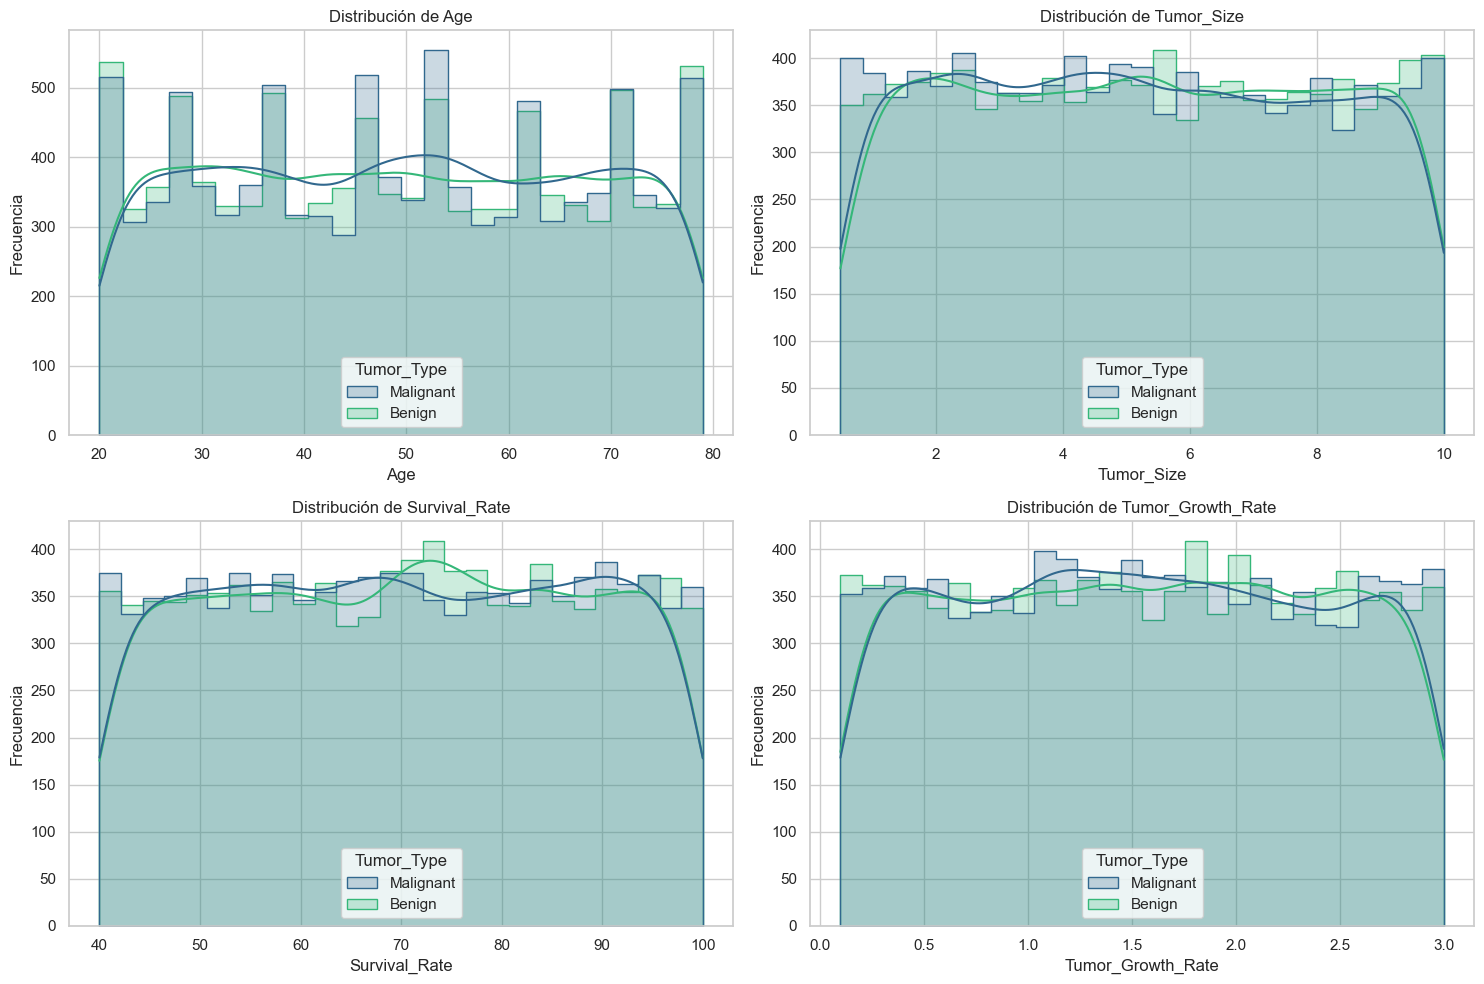

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar los datos
df = pd.read_csv('brain_tumor_dataset.csv')

# 2. Configurar el estilo visual
sns.set_theme(style="whitegrid")
cols_numericas = ['Age', 'Tumor_Size', 'Survival_Rate', 'Tumor_Growth_Rate']

# 3. Crear los histogramas
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, hue='Tumor_Type', kde=True, element="step", palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Para preparar los datos para el modelo:
- Se transformó la variable objetivo a valores binarios (Malignant = 1, Benign = 0).
- Se eliminaron variables no relevantes.
- Las variables categóricas se codificaron mediante *one-hot encoding*.
- Se utilizó un **Pipeline** para integrar el escalado de las variables y el modelo, evitando problemas de *data leakage*.

In [12]:
y = df['Tumor_Type'].map({'Malignant': 1, 'Benign': 0})
X = df.drop(columns=['Patient_ID', 'Tumor_Type'])
X = pd.get_dummies(X, drop_first=True)

Se implementó un Support Vector Classifier (SVC) con kernel lineal.  
El hiperparámetro C controla el equilibrio entre la maximización del margen y la minimización de errores de clasificación.

In [13]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Manejo de valores faltantes
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear', probability=True))
])

In [14]:
search_space = {
    'svc__C': Real(0.01, 10.0, prior='log-uniform')
}


In [ ]:
# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

El hiperparámetro C fue optimizado utilizando BayesSearchCV, maximizando el AUC promedio mediante validación cruzada estratificada de **10 folds**. Este enfoque permite encontrar de manera eficiente el valor de C que ofrece el mejor desempeño del modelo.

In [17]:
# Optimización bayesiana
opt = BayesSearchCV(
    estimator=pipeline,
    search_spaces=search_space,
    n_iter=20,               # Más iteraciones para una mejor búsqueda
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

opt.fit(X, y)

,estimator,Pipeline(step...ility=True))])
,search_spaces,{'svc__C': Real(low=0.01...m='normalize')}
,optimizer_kwargs,None
,n_iter,20
,scoring,'roc_auc'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,StratifiedKFo... shuffle=True)


In [18]:
# Resultados
print("-" * 30)
print(f"Mejor AUC promedio: {opt.best_score_:.4f}")
print(f"Mejor valor de C: {opt.best_params_['svc__C']:.4f}")

------------------------------
Mejor AUC promedio: 0.4956
Mejor valor de C: 7.3525


El mejor modelo obtuvo un AUC promedio de 0.4956 con un valor óptimo de C = 7.3525, lo que indica una capacidad discriminativa equivalente al azar.

## Conclusiones

A pesar de la optimización bayesiana, el modelo SVC con kernel lineal no logró discriminar eficazmente entre tumores benignos y malignos, lo que sugiere que el dataset no contiene suficiente información predictiva o que la relación entre las variables es de naturaleza no lineal.